# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MotazSameh/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

### 1. Distributions

I will inspect the distributions of the main signals used for content prioritization: `impressions_90d`, `days_since_last_update`, `avg_position`, and `ctr`.

The goal is to understand the data before defining signal rules. In particular, I will look for skewed or heavy-tailed variables where a small number of pages have much larger values than most pages.


In [1]:
# ============================================================
# ML-06 — Section 1: Distributions
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the starter dataset
df = pd.read_csv("content_refresh_anonymized.csv")

# Create target only for analysis
df["is_declining"] = (
    df["trend_direction"]
    .str.lower()
    .eq("down")
    .astype(int)
)

signals = [
    "impressions_90d",
    "days_since_last_update",
    "avg_position",
    "ctr"
]

# Summary statistics
distribution_summary = df[signals].describe().T

distribution_summary["missing"] = df[signals].isna().sum()

distribution_summary["skew"] = (
    df[signals]
    .skew()
)

display(distribution_summary)

,count,mean,std,min,25%,50%,75%,max,missing,skew
impressions_90d,30000.0,5200.366300,16838.019547,1.0,81.0,731.00,3615.25,517715.0,0,11.384919
days_since_last_update,30000.0,46.098300,42.078709,1.0,20.0,20.00,104.00,373.0,0,1.161283
avg_position,30000.0,16.342380,15.216790,0.0,6.2,10.80,22.30,245.0,0,1.984214
ctr,30000.0,0.510733,3.279162,0.0,0.0,0.07,0.29,100.0,0,17.444252


In [2]:
# Check important quantiles
quantiles = df[signals].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99]
).T

display(quantiles)

,0.50,0.75,0.90,0.95,0.99
impressions_90d,731.00,3615.25,12136.40,22996.50,73505.830
days_since_last_update,20.00,104.00,104.00,104.00,106.000
avg_position,10.80,22.30,36.80,48.20,69.901
ctr,0.07,0.29,0.65,1.09,8.330


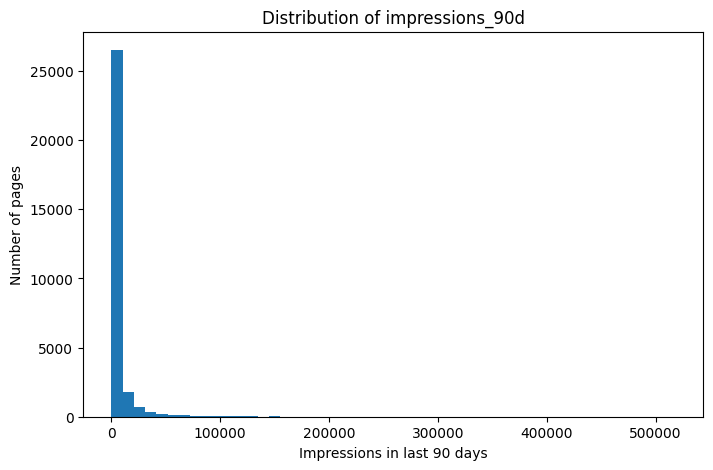

In [3]:
# Distribution of impressions
plt.figure(figsize=(8, 5))

plt.hist(
    df["impressions_90d"].dropna(),
    bins=50
)

plt.xlabel("Impressions in last 90 days")
plt.ylabel("Number of pages")
plt.title("Distribution of impressions_90d")

plt.show()

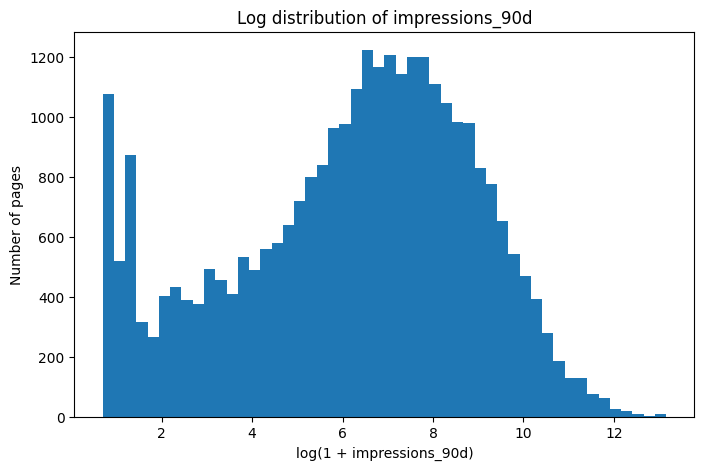

In [4]:
plt.figure(figsize=(8, 5))

plt.hist(
    np.log1p(df["impressions_90d"].dropna()),
    bins=50
)

plt.xlabel("log(1 + impressions_90d)")
plt.ylabel("Number of pages")
plt.title("Log distribution of impressions_90d")

plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

### Signal test #1 — Visibility

I expect pages with higher observed impressions to have a different declining rate than pages with very low impressions.

I will compare declining rates across visibility buckets. This is a directional signal test, not evidence that impressions cause decline.


In [5]:
# ============================================================
# Signal Test #1 — Visibility
# ============================================================

df["visibility_bucket"] = pd.cut(
    df["impressions_90d"],
    bins=[-np.inf, 100, 500, 1000, np.inf],
    labels=["0-100", "101-500", "501-1000", "1000+"]
)

visibility_test = (
    df.groupby("visibility_bucket", observed=False)
      .agg(
          n=("is_declining", "size"),
          declining_rate=("is_declining", "mean")
      )
)

visibility_test["declining_rate"] = (
    visibility_test["declining_rate"] * 100
).round(2)

display(visibility_test)

,n,declining_rate
visibility_bucket,,
0-100,8006,38.92
101-500,5279,60.43
501-1000,3206,60.04
1000+,13509,59.45


**Verdict: CONFIRMED**

The data directionally supports the visibility signal. Pages with more than 100 impressions have substantially higher observed declining rates than pages with 100 or fewer impressions. This is an observed association, not a causal claim.


### Signal test #2 — Staleness

I expect pages that have not been updated for longer to show a different observed declining rate.

I will compare declining rates across update-recency buckets and look for a directional relationship.


In [6]:
# ============================================================
# Signal Test #2 — Staleness
# ============================================================

df["staleness_bucket"] = pd.cut(
    df["days_since_last_update"],
    bins=[-np.inf, 30, 90, 180, np.inf],
    labels=[
        "0-30 days",
        "31-90 days",
        "91-180 days",
        "181+ days"
    ]
)

staleness_test = (
    df.groupby("staleness_bucket", observed=False)
      .agg(
          n=("is_declining", "size"),
          declining_rate=("is_declining", "mean")
      )
)

staleness_test["declining_rate"] = (
    staleness_test["declining_rate"] * 100
).round(2)

display(staleness_test)

,n,declining_rate
staleness_bucket,,
0-30 days,20480,51.14
31-90 days,175,58.86
91-180 days,9171,61.11
181+ days,174,47.13


**Verdict: MIXED**

The data shows higher observed declining rates for pages in the 91–180 day bucket, but the 181+ day bucket does not follow the same direction and contains relatively few observations. Therefore, staleness appears directionally useful, but the relationship is not consistent across all buckets.


### Signal test #3 — CTR relative to position

A page can have reasonable search visibility but still receive a relatively low click-through rate. I will compare observed declining rates for pages with stronger and weaker CTR, while also considering average position.

This test checks whether the combination provides a useful directional signal. It does not establish that low CTR causes decline.


In [7]:
# ============================================================
# Signal Test #3 — CTR + Position
# ============================================================

# Keep the test simple and interpretable.
# Lower position values mean better average ranking.

df["position_bucket"] = pd.cut(
    df["avg_position"],
    bins=[-np.inf, 10, 20, np.inf],
    labels=["1-10", "11-20", "20+"]
)

df["ctr_bucket"] = pd.cut(
    df["ctr"],
    bins=[-np.inf, 0.05, 0.20, np.inf],
    labels=["Low CTR", "Medium CTR", "High CTR"]
)

ctr_position_test = (
    df.groupby(
        ["position_bucket", "ctr_bucket"],
        observed=False
    )
    .agg(
        n=("is_declining", "size"),
        declining_rate=("is_declining", "mean")
    )
)

ctr_position_test["declining_rate"] = (
    ctr_position_test["declining_rate"] * 100
).round(2)

display(ctr_position_test)

n  declining_rate
position_bucket ctr_bucket                      
1-10            Low CTR     6189           45.82
                Medium CTR  2462           63.36
                High CTR    5537           52.79
11-20           Low CTR     3093           64.21
                Medium CTR  1637           62.06
                High CTR    2543           56.27
20+             Low CTR     5137           50.75
                Medium CTR  1787           61.33
                High CTR    1615           49.97

**Verdict: MIXED**

The CTR and position buckets do not provide one consistent pattern across all groups. Some groups show higher observed declining rates, while others do not. This makes the signal potentially useful for investigation, but not strong enough to use alone as a decision rule.


## 3. The flag-linked test

The refresh flag relies on content staleness as one of its underlying signals. I will therefore test whether pages that have been unchanged for at least 91 days show a higher observed declining rate than pages updated more recently.

The result will be treated as directional evidence for the signal, not as proof that staleness causes declining performance.


In [8]:
# ============================================================
# Section 3 — Flag-linked test: Staleness
# ============================================================

df["stale_91_plus"] = (
    df["days_since_last_update"] >= 91
)

flag_linked_test = (
    df.groupby("stale_91_plus")
      .agg(
          n=("is_declining", "size"),
          declining_rate=("is_declining", "mean")
      )
)

flag_linked_test["declining_rate"] = (
    flag_linked_test["declining_rate"] * 100
).round(2)

display(flag_linked_test)

,n,declining_rate
stale_91_plus,,
False,20655,51.20
True,9345,60.85


In [9]:
# Compare the two groups

recent_rate = (
    flag_linked_test.loc[False, "declining_rate"]
)

stale_rate = (
    flag_linked_test.loc[True, "declining_rate"]
)

print("Declining rate for <91 days:",
      recent_rate, "%")

print("Declining rate for >=91 days:",
      stale_rate, "%")

print("Difference:",
      round(stale_rate - recent_rate, 2),
      "percentage points")

Declining rate for <91 days: 51.2 %
Declining rate for >=91 days: 60.85 %
Difference: 9.65 percentage points


**Verdict: CONFIRMED — directionally**

The flag-linked test shows a higher observed declining rate among pages that have not been updated for at least 91 days. This supports staleness as a directional signal behind a refresh-prioritization rule. It does not prove that refreshing a page will cause its performance to improve.


## 4. What this means in practice

The audit suggests that visibility and staleness can provide useful directional signals for prioritizing content, but neither signal is sufficient on its own. The mixed results for CTR and position also suggest that a content team should treat the baseline as decision-support rather than as an automatic refresh decision. Pages selected by the rule should still be reviewed in context before action is taken.


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.